## Perceptrón Multicapa (MLP) entrenado para dataset de detección visual de personajes de los Simpsons

<p align="center"><img src="../images/logoLosSimpsons.png" alt="Logo de Los Simpsons" width="600"></p>

#### Integrantes:

    - VINCENT FARENDEN CERON
    - RODRIGO IGNACIO MARTINEZ BECKER
    - DIEGO IGNACIO PENA Y LILLO LUHRS

#### Asignatura:

    - MACHINE LEARNING_001D

#### Profesor:

    - FRANCISCO JAVIER JEREZ SALAZAR

#### Fecha:

    - 13-09-2026

## Definición del Dataset

Nuestro conjunto de datos se presenta como dos carpetas de entreno y pruebas en donde ambas presentan la misma estructura de imagenes, una carpeta por personaje definido con varias imagenes de estos desde varios puntos de vista. Nosotros escogimos este dataset debido a la gran popularidad de los personajes y porque tienen una identidad gráfica extremadamente reconocible: piel amarilla, siluetas simples, colores fuertes y personajes fáciles de distinguir incluso con pocos detalles. Su diseño es consistente y memorable, lo que hace que la serie destaque inmediatamente frente a otras animaciones.

![Homero](../images/homero.png) ![Lisa](../images/lisa.png)

## Definición del problema de clasificación

El problema que abordamos es de **clasificación de imágenes multiclase de etiqueta única**: dada una imagen RGB que contiene a un personaje de Los Simpsons, el modelo debe asignarle **exactamente una** de las 25 clases posibles (una por personaje). No es detección de objetos ni clasificación multi-etiqueta: no se predicen cajas delimitadoras ni varios personajes por imagen.

**Entrada y salida**

- **Entrada (X):** imagen RGB de tamaño variable (aprox. entre 256x257 y 720x464 px). Para el Perceptrón Multicapa se redimensionará a un tamaño fijo, se normalizarán los píxeles al rango [0, 1] y se aplanará la imagen en un vector, ya que el MLP no acepta estructura espacial 2D.
- **Salida (y):** vector de 25 probabilidades (activación *softmax*); la clase predicha es la de mayor probabilidad.
- **Función de pérdida:** entropía cruzada categórica (*categorical crossentropy*).

**Conjuntos de datos**

| Conjunto | Imágenes | Clases |
|---|---|---|
| train | 16.137 | 25 |
| test | 3.937 | 25 |

**Desbalance de clases**

Las clases están fuertemente desbalanceadas: en entrenamiento van desde 1.796 imágenes de `homer_simpson` hasta 82 de `selma_bouvier` (razón aproximada de 22:1). Esto implica que la *accuracy* por sí sola es una métrica engañosa, y que el modelo tenderá a favorecer a los personajes mayoritarios.

**Baselines de referencia**

- Clasificador aleatorio: 1/25 = **4,0 %** de accuracy.
- Clasificador de clase mayoritaria (predecir siempre `homer_simpson`): 450/3.937 = **11,4 %** en test.

Cualquier modelo útil debe superar claramente estos valores.

**Métricas de evaluación**

Además de la *accuracy* global se reportarán **precision, recall y F1-score por clase**, el **F1 macro** (que pondera igual a todas las clases, mostrando el efecto del desbalance) y la **matriz de confusión**, útil para detectar confusiones sistemáticas entre personajes visualmente parecidos (por ejemplo, Bart y Milhouse, o Lisa y Maggie).

**Dificultades esperadas**

Como se puede ver en las imágenes del apartado anterior, tanto Homero como Lisa aparecen en múltiples poses, con distintos encuadres, escalas y fondos, y con variaciones de color debidas a las diferentes temporadas. A esto se suman personajes parcialmente ocluidos o acompañados por otros en la misma escena, y la pérdida de información espacial al aplanar la imagen para el MLP, lo que limita el rendimiento alcanzable frente a arquitecturas convolucionales.

**Supuestos**

Se asume que cada imagen contiene un único personaje relevante (el que da nombre a su carpeta) y que la partición train/test provista por el dataset es válida, es decir, que no existen imágenes duplicadas entre ambos conjuntos.

## Pre-Procesamiento de los datos

En esta sección se prepara el dataset para que pueda ser consumido por una red densa: se cargan las rutas e imágenes, se llevan todas a un tamaño fijo, se normalizan los valores de píxel, se aplanan a vectores y se codifican las etiquetas.

### Definición del conjunto de datos a utilizar

In [25]:
from pathlib import Path

DATASET_BASE = Path("C:/Users/Diego/Desktop/Trabajos/LosSimpsonsDataset")
CONJUNTOS_VALIDOS = ("train", "test")

# Cambiar a ( 'train' / 'test' ) según lel conjunto que quieras correr
conjunto = "train"

conjunto = conjunto.strip().lower()
if conjunto not in CONJUNTOS_VALIDOS:
    raise ValueError(
        f'Conjunto inválido: "{conjunto}". Usa uno de: {CONJUNTOS_VALIDOS}'
    )

direccion_dataset = DATASET_BASE / conjunto

if not direccion_dataset.is_dir():
    raise FileNotFoundError(f"No existe el directorio: {direccion_dataset}")

print(f'Se está utilizando el conjunto "{conjunto}" en: {direccion_dataset}')

Se está utilizando el conjunto "train" en: C:\Users\Diego\Desktop\Trabajos\LosSimpsonsDataset\train


### Carga de imágenes y etiquetas

In [26]:
import pandas as pd

EXTENSIONES_VALIDAS = (".jpg", ".jpeg", ".png", ".bmp")


def construir_indice(directorio):
    """Recorre un directorio con una subcarpeta por clase y devuelve un
    DataFrame con la ruta de cada imagen y el personaje al que pertenece."""
    registros = []

    for carpeta_clase in sorted(directorio.iterdir()):
        if not carpeta_clase.is_dir():
            continue

        for ruta in sorted(carpeta_clase.iterdir()):
            if ruta.suffix.lower() in EXTENSIONES_VALIDAS:
                registros.append({"ruta": ruta, "personaje": carpeta_clase.name})

    if not registros:
        raise FileNotFoundError(f"No se encontraron imagenes en: {directorio}")

    return pd.DataFrame(registros)


# Indice del conjunto seleccionado en el paso anterior
datos = construir_indice(direccion_dataset)

# Lista ordenada de clases y su mapeo a indices enteros
clases = sorted(datos["personaje"].unique())
clase_a_indice = {clase: indice for indice, clase in enumerate(clases)}
indice_a_clase = {indice: clase for clase, indice in clase_a_indice.items()}

# Etiqueta numerica de cada imagen
datos["etiqueta"] = datos["personaje"].map(clase_a_indice)

# Resumen de imagenes por clase como DataFrame
resumen = (
    datos["personaje"]
    .value_counts()
    .rename_axis("personaje")
    .reset_index(name="imagenes")
)
resumen["etiqueta"] = resumen["personaje"].map(clase_a_indice)
resumen["porcentaje"] = (resumen["imagenes"] / len(datos) * 100).round(2)
resumen = resumen[["etiqueta", "personaje", "imagenes", "porcentaje"]]

print(f'Conjunto "{conjunto}": {len(datos)} imagenes en {len(clases)} clases')

display(resumen)


Conjunto "train": 16137 imagenes en 25 clases


,etiqueta,personaje,imagenes,porcentaje
0,9,homer_simpson,1796,11.13
1,19,ned_flanders,1163,7.21
2,18,moe_szyslak,1161,7.19
3,13,lisa_simpson,1083,6.71
4,3,bart_simpson,1073,6.65
5,15,marge_simpson,1032,6.40
6,11,krusty_the_clown,964,5.97
7,21,principal_skinner,955,5.92
8,4,charles_montgomery_burns,954,5.91
9,17,milhouse_van_houten,863,5.35


### Redimensionado a un tamaño fijo



In [27]:
from PIL import Image
import numpy as np

# Dimensiones originales de cada imagen del conjunto (sin cargar los pixeles)
dimensiones = []
for ruta in datos["ruta"]:
    with Image.open(ruta) as img:
        dimensiones.append(img.size)  # (ancho, alto)

datos["ancho"] = [ancho for ancho, _ in dimensiones]
datos["alto"] = [alto for _, alto in dimensiones]

resumen_dimensiones = datos[["ancho", "alto"]].describe().T
resumen_dimensiones["mediana"] = datos[["ancho", "alto"]].median()
resumen_dimensiones = resumen_dimensiones[
    ["count", "min", "25%", "mediana", "75%", "max", "mean", "std"]
].round(1)

display(resumen_dimensiones)


,count,min,25%,mediana,75%,max,mean,std
ancho,16137.0,256.0,288.0,320.0,576.0,1912.0,408.5,149.0
alto,16137.0,256.0,379.0,432.0,480.0,1072.0,416.4,63.1


**Elección y justificación del tamaño objetivo**

Las imágenes del conjunto tienen dimensiones variables, mientras que una red densa exige un vector de
entrada de longitud fija. Por lo tanto, el primer paso del pre-procesamiento consiste en llevar todas
las imágenes a una misma resolución.

La elección de esa resolución no es arbitraria, ya que condiciona directamente el tamaño del modelo.
Al aplanar la imagen, la capa de entrada queda formada por `alto x ancho x 3` valores (tres canales
RGB por píxel) y cada uno de ellos se conecta con todas las neuronas de la primera capa oculta. En
consecuencia, el número de parámetros de esa capa crece de forma cuadrática respecto del lado de la
imagen:

| Resolución | Dimensión del vector de entrada | Parámetros de la primera capa densa (512 neuronas) |
|---|---|---|
| 32 x 32 | 3.072 | ≈ 1,6 millones |
| **64 x 64** | **12.288** | **≈ 6,3 millones** |
| 128 x 128 | 49.152 | ≈ 25,2 millones |

Se adopta una resolución de **64 x 64 píxeles**, por tres razones:

1. **Suficiencia informativa.** A esa escala se conservan los rasgos que permiten discriminar entre
   personajes —silueta, color de piel, peinado y vestimenta—, que en Los Simpsons son elementos de
   diseño muy marcados y de baja frecuencia espacial, poco sensibles a la pérdida de detalle fino.
2. **Costo computacional acotado.** Duplicar el lado a 128 x 128 cuadruplica la dimensión de entrada
   y, con ella, los parámetros entrenables. Esto aumenta el tiempo de entrenamiento y el riesgo de
   sobreajuste, sin un beneficio equivalente: al aplanar la imagen el MLP pierde la estructura
   espacial, por lo que no puede explotar el detalle adicional como sí lo haría una red convolucional.
3. **Pérdida de información en resoluciones menores.** Con 32 x 32 el modelo sería más económico,
   pero la degradación compromete la distinción entre personajes visualmente similares.

En síntesis, 64 x 64 representa un compromiso razonable entre el detalle conservado y la complejidad
del modelo. Este valor se fija como referencia para el modelo base y podrá revisarse en la etapa de
experimentación.


In [28]:
ALTO_OBJETIVO, ANCHO_OBJETIVO = 64, 64
TAMANO_OBJETIVO = (ANCHO_OBJETIVO, ALTO_OBJETIVO)  # PIL usa (ancho, alto)


def cargar_y_redimensionar(ruta, tamano=TAMANO_OBJETIVO):
    """Abre una imagen, la convierte a RGB y la redimensiona al tamano fijo."""
    with Image.open(ruta) as img:
        img = img.convert("RGB").resize(tamano, Image.Resampling.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


# Matriz de imagenes redimensionadas: (n_imagenes, alto, ancho, 3)
imagenes = np.stack([cargar_y_redimensionar(ruta) for ruta in datos["ruta"]])
etiquetas = datos["etiqueta"].to_numpy()

print(f"imagenes: {imagenes.shape}  dtype={imagenes.dtype}")
print(f"etiquetas: {etiquetas.shape}")


imagenes: (16137, 64, 64, 3)  dtype=uint8
etiquetas: (16137,)


**Comprobación del redimensionado**

In [29]:
comprobaciones = pd.DataFrame(
    [
        ("Numero de imagenes", imagenes.shape[0], len(datos), imagenes.shape[0] == len(datos)),
        ("Alto", imagenes.shape[1], ALTO_OBJETIVO, imagenes.shape[1] == ALTO_OBJETIVO),
        ("Ancho", imagenes.shape[2], ANCHO_OBJETIVO, imagenes.shape[2] == ANCHO_OBJETIVO),
        ("Canales", imagenes.shape[3], 3, imagenes.shape[3] == 3),
        ("Tipo de dato", str(imagenes.dtype), "uint8", imagenes.dtype == np.uint8),
        ("Valor minimo", int(imagenes.min()), ">= 0", imagenes.min() >= 0),
        ("Valor maximo", int(imagenes.max()), "<= 255", imagenes.max() <= 255),
        ("Etiquetas alineadas", len(etiquetas), imagenes.shape[0], len(etiquetas) == imagenes.shape[0]),
    ],
    columns=["comprobacion", "obtenido", "esperado", "ok"],
)

memoria_mb = imagenes.nbytes / 1024**2
print(f"Memoria ocupada por la matriz de imagenes: {memoria_mb:.1f} MB")
print(f"Neuronas en la capa de entrada tras aplanar: {ALTO_OBJETIVO * ANCHO_OBJETIVO * 3}")

display(comprobaciones)


Memoria ocupada por la matriz de imagenes: 189.1 MB
Neuronas en la capa de entrada tras aplanar: 12288


,comprobacion,obtenido,esperado,ok
0,Numero de imagenes,16137,16137,True
1,Alto,64,64,True
2,Ancho,64,64,True
3,Canales,3,3,True
4,Tipo de dato,uint8,uint8,True
5,Valor minimo,0,>= 0,True
6,Valor maximo,255,<= 255,True
7,Etiquetas alineadas,16137,16137,True


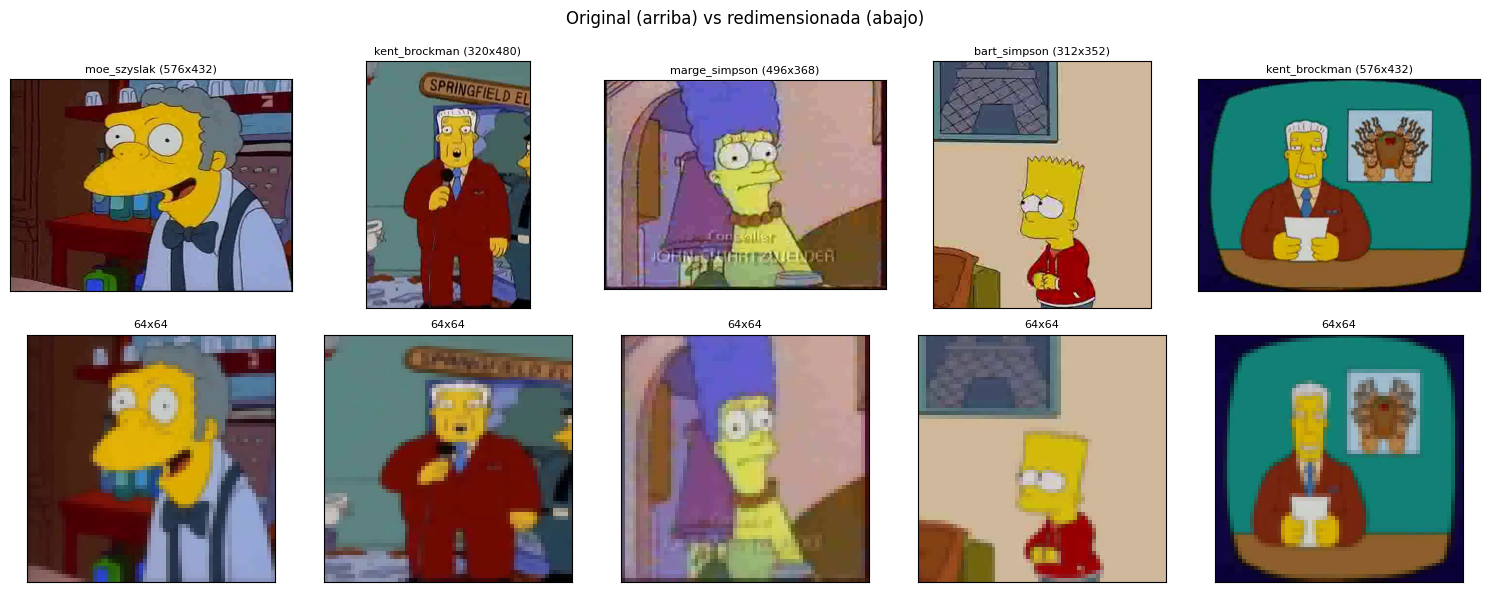

In [30]:
import matplotlib.pyplot as plt

# Comparacion visual original vs redimensionada para una muestra aleatoria
generador = np.random.default_rng(42)
muestra = generador.choice(len(datos), size=5, replace=False)

figura, ejes = plt.subplots(2, len(muestra), figsize=(3 * len(muestra), 6))
for columna, indice in enumerate(muestra):
    fila = datos.iloc[indice]
    with Image.open(fila["ruta"]) as img:
        original = img.convert("RGB")

    titulo = "{} ({}x{})".format(fila["personaje"], original.size[0], original.size[1])
    ejes[0, columna].imshow(original)
    ejes[0, columna].set_title(titulo, fontsize=8)
    ejes[1, columna].imshow(imagenes[indice])
    ejes[1, columna].set_title("{}x{}".format(ANCHO_OBJETIVO, ALTO_OBJETIVO), fontsize=8)

    for eje in (ejes[0, columna], ejes[1, columna]):
        eje.set_xticks([])
        eje.set_yticks([])

figura.suptitle("Original (arriba) vs redimensionada (abajo)")
figura.tight_layout()
plt.show()


### Normalización de los píxeles



**Por que normalizar**

Los pixeles se almacenan como enteros `uint8` en el rango [0, 255]. Si se alimentan directamente a la
red, las combinaciones lineales de la primera capa producen valores de magnitud muy grande: las
activaciones sigmoide o tanh se saturan (gradiente practicamente nulo) y, con ReLU, los gradientes
resultan muy dispares entre si, lo que obliga a usar tasas de aprendizaje muy pequenas y hace
inestable el descenso del gradiente.

Al dividir por 255 todas las caracteristicas de entrada quedan en la misma escala acotada [0, 1]. Esto
mantiene las preactivaciones en un rango razonable, hace comparables las magnitudes de los gradientes
entre pixeles y permite que la inicializacion estandar de los pesos de Keras funcione como se espera.

Se convierte ademas a `float32`, que es el tipo con el que opera Keras: es la mitad de memoria que
`float64` y evita conversiones implicitas en cada batch.


In [31]:
# Escalado de [0, 255] a [0, 1] en float32 (tipo con el que opera Keras)
VALOR_MAXIMO_PIXEL = 255.0

imagenes_norm = imagenes.astype(np.float32) / VALOR_MAXIMO_PIXEL

memoria_mb = imagenes_norm.nbytes / (1024**2)

print(f"imagenes_norm: {imagenes_norm.shape}  dtype={imagenes_norm.dtype}")
print(f"rango: [{imagenes_norm.min():.3f}, {imagenes_norm.max():.3f}]")
print(f"media: {imagenes_norm.mean():.4f}  desviacion: {imagenes_norm.std():.4f}")
print(f"memoria ocupada: {memoria_mb:.1f} MB")


imagenes_norm: (16137, 64, 64, 3)  dtype=float32
rango: [0.000, 1.000]
media: 0.4066  desviacion: 0.2448
memoria ocupada: 756.4 MB


**Comprobacion de la normalizacion**

In [32]:
indice_prueba = 0

comprobaciones_norm = pd.DataFrame(
    [
        (
            "Forma conservada",
            str(imagenes_norm.shape),
            str(imagenes.shape),
            imagenes_norm.shape == imagenes.shape,
        ),
        (
            "Tipo de dato",
            str(imagenes_norm.dtype),
            "float32",
            imagenes_norm.dtype == np.float32,
        ),
        (
            "Valor minimo",
            round(float(imagenes_norm.min()), 4),
            ">= 0.0",
            imagenes_norm.min() >= 0.0,
        ),
        (
            "Valor maximo",
            round(float(imagenes_norm.max()), 4),
            "<= 1.0",
            imagenes_norm.max() <= 1.0,
        ),
        (
            "Sin NaN ni infinitos",
            bool(np.isfinite(imagenes_norm).all()),
            True,
            bool(np.isfinite(imagenes_norm).all()),
        ),
        (
            "Escalado exacto (x255 == original)",
            "imagenes_norm * 255",
            "imagenes",
            np.allclose(
                imagenes_norm[indice_prueba] * VALOR_MAXIMO_PIXEL,
                imagenes[indice_prueba].astype(np.float32),
            ),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_norm)

if not comprobaciones_norm["Correcto"].all():
    raise ValueError("La normalizacion no cumple alguna de las comprobaciones.")

print("Normalizacion verificada correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Forma conservada,"(16137, 64, 64, 3)","(16137, 64, 64, 3)",True
1,Tipo de dato,float32,float32,True
2,Valor minimo,0.0,>= 0.0,True
3,Valor maximo,1.0,<= 1.0,True
4,Sin NaN ni infinitos,True,True,True
5,Escalado exacto (x255 == original),imagenes_norm * 255,imagenes,True


Normalizacion verificada correctamente.


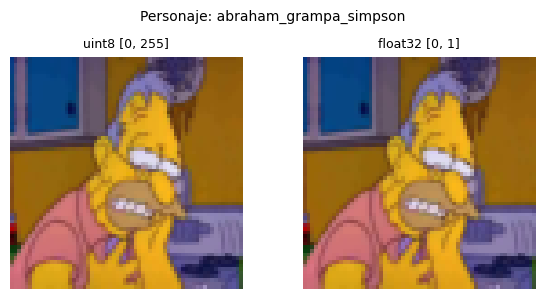

In [33]:
# La imagen normalizada debe verse identica a la original: solo cambia la escala numerica
figura, ejes = plt.subplots(1, 2, figsize=(6, 3))

ejes[0].imshow(imagenes[indice_prueba])
ejes[0].set_title("uint8 [0, 255]", fontsize=9)
ejes[1].imshow(imagenes_norm[indice_prueba])
ejes[1].set_title("float32 [0, 1]", fontsize=9)
for eje in ejes:
    eje.axis("off")

figura.suptitle(f"Personaje: {datos.iloc[indice_prueba]['personaje']}", fontsize=10)
plt.tight_layout()
plt.show()


### Vectorización (aplanado) de las imágenes

**Por que aplanar y que implica**

Una capa densa (`Dense`) recibe un vector: cada neurona se conecta con **todas** las entradas mediante
un peso. No tiene forma de aprovechar que dos pixeles esten uno al lado del otro, porque en su interior
todas las entradas son intercambiables. Por eso la imagen de `alto x ancho x 3` debe convertirse en un
unico vector de longitud fija `alto * ancho * 3`.

Con el tamano elegido en "Redimensionado a un tamano fijo" esto da **64 x 64 x 3 = 12 288** valores por imagen, que es exactamente la
dimension de la capa de entrada del MLP.

El aplanado es el paso donde se **pierde la estructura espacial**: el modelo ya no sabe que el pixel
`(0, 0)` y el `(0, 1)` eran vecinos. Esta es precisamente la limitacion que se discute en "Limitaciones del MLP en imagenes y propuestas de mejora"
y el motivo por el que una CNN, que si preserva esa vecindad, resulta mas adecuada para imagenes.



**Por que `X` tiene dos dimensiones e `y` solo una**

`X` es una **matriz**: una fila por imagen y una columna por caracteristica de entrada. Su forma
`(16137, 12288)` se lee como "16 137 ejemplos, cada uno descrito por 12 288 numeros". La primera
dimension siempre cuenta ejemplos y la segunda las caracteristicas de cada uno; es el formato que Keras
espera para alimentar una capa densa, que procesa las filas por lotes (batches).

`y` es un **vector**: su forma `(16137,)` significa "16 137 etiquetas", una por fila de `X`. Para
describir a que personaje corresponde una imagen basta con un unico numero (el indice de la clase), asi
que no hace falta una segunda dimension. Lo unico imprescindible es que `X.shape[0] == y.shape[0]` y que
el orden coincida: la etiqueta `y[i]` corresponde a la imagen `X[i]`.

Esa asimetria es solo del estado actual de los datos, no una regla: en "Codificacion de las etiquetas"
se aplicara one-hot encoding y `y` pasara a ser tambien una matriz `(16137, 25)`, con una columna por
personaje, que es lo que exige la perdida `categorical_crossentropy`.

El orden del aplanado es `C` (por filas: fila a fila, y dentro de cada fila los tres canales RGB de cada
pixel). Lo importante no es el orden concreto, sino que sea **el mismo para todas las imagenes** y para
los conjuntos de train y test, cosa que `reshape` garantiza al aplicarse sobre el arreglo completo.


In [34]:
# Cada imagen (alto, ancho, 3) pasa a ser un vector de alto * ancho * 3 valores
DIMENSION_ENTRADA = ALTO_OBJETIVO * ANCHO_OBJETIVO * 3

X = imagenes_norm.reshape(imagenes_norm.shape[0], -1)
y = etiquetas

print(f"X: {X.shape}  dtype={X.dtype}")
print(f"y: {y.shape}")
print(f"Dimension de la capa de entrada: {DIMENSION_ENTRADA}")
print(f"rango de X: [{X.min():.3f}, {X.max():.3f}]")


X: (16137, 12288)  dtype=float32
y: (16137,)
Dimension de la capa de entrada: 12288
rango de X: [0.000, 1.000]


**Comprobacion del aplanado**

In [35]:
# El aplanado debe ser reversible: recuperar la imagen original desde su vector
imagen_reconstruida = X[indice_prueba].reshape(ALTO_OBJETIVO, ANCHO_OBJETIVO, 3)

comprobaciones_aplanado = pd.DataFrame(
    [
        (
            "Numero de imagenes",
            X.shape[0],
            imagenes_norm.shape[0],
            X.shape[0] == imagenes_norm.shape[0],
        ),
        (
            "Longitud del vector",
            X.shape[1],
            DIMENSION_ENTRADA,
            X.shape[1] == DIMENSION_ENTRADA,
        ),
        ("Numero de dimensiones", X.ndim, 2, X.ndim == 2),
        ("Tipo de dato", str(X.dtype), "float32", X.dtype == np.float32),
        (
            "Rango conservado [0, 1]",
            f"[{X.min():.3f}, {X.max():.3f}]",
            "[0.0, 1.0]",
            bool(X.min() >= 0.0 and X.max() <= 1.0),
        ),
        (
            "Aplanado reversible",
            "X[i].reshape(alto, ancho, 3)",
            "imagenes_norm[i]",
            np.array_equal(imagen_reconstruida, imagenes_norm[indice_prueba]),
        ),
        ("Etiquetas alineadas", len(y), X.shape[0], len(y) == X.shape[0]),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_aplanado)

if not comprobaciones_aplanado["Correcto"].all():
    raise ValueError("El aplanado no cumple alguna de las comprobaciones.")

print("Aplanado verificado correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Numero de imagenes,16137,16137,True
1,Longitud del vector,12288,12288,True
2,Numero de dimensiones,2,2,True
3,Tipo de dato,float32,float32,True
4,"Rango conservado [0, 1]","[0.000, 1.000]","[0.0, 1.0]",True
5,Aplanado reversible,"X[i].reshape(alto, ancho, 3)",imagenes_norm[i],True
6,Etiquetas alineadas,16137,16137,True


Aplanado verificado correctamente.


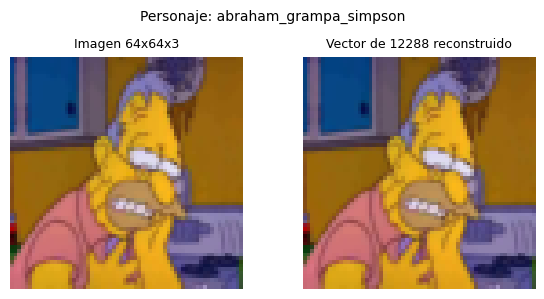

In [36]:
# Al reconstruir el vector se recupera exactamente la misma imagen
figura, ejes = plt.subplots(1, 2, figsize=(6, 3))

ejes[0].imshow(imagenes_norm[indice_prueba])
ejes[0].set_title(f"Imagen {ALTO_OBJETIVO}x{ANCHO_OBJETIVO}x3", fontsize=9)
ejes[0].axis("off")

ejes[1].imshow(imagen_reconstruida)
ejes[1].set_title(f"Vector de {DIMENSION_ENTRADA} reconstruido", fontsize=9)
ejes[1].axis("off")

figura.suptitle(f"Personaje: {datos.iloc[indice_prueba]['personaje']}", fontsize=10)
plt.tight_layout()
plt.show()


### Codificación de las etiquetas

_Mapear los 25 nombres de personaje a índices enteros y aplicar one-hot encoding, coherente con la función de pérdida categorical_crossentropy._

**De nombre de carpeta a vector one-hot**

Las etiquetas nacen como texto (el nombre de la carpeta, por ejemplo `homer_simpson`) y una red no opera
con texto, asi que hay que convertirlas a numeros. La conversion se hace en dos pasos:

1. **Indice entero.** Ya se construyo en "Carga de imagenes y etiquetas": `clases` es la lista de
   personajes ordenada alfabeticamente y `clase_a_indice` asigna a cada uno un entero de 0 a 24. Ese
   mapeo se reutiliza aqui en lugar de recalcularlo, porque debe ser **identico en train y en test**: si
   el indice 3 significara un personaje distinto en cada conjunto, la evaluacion no tendria sentido.

2. **One-hot encoding.** El indice entero por si solo es enganoso para el modelo: sugiere un **orden** y
   una **distancia** que no existen (que la clase 5 este "entre" la 4 y la 6, o que la 24 sea "mayor" que
   la 1). Los personajes son categorias nominales, sin orden. El one-hot elimina ese artefacto
   representando cada etiqueta como un vector de 25 posiciones con un 1 en la clase correcta y 0 en el
   resto, de modo que todas las clases quedan a la misma distancia entre si.

Ademas, esta forma es la que corresponde a la salida de la red: la capa final tiene 25 neuronas con
`softmax`, que produce un vector de 25 probabilidades. La perdida `categorical_crossentropy` compara ese
vector con el one-hot real, penalizando la probabilidad asignada a la clase verdadera.

> Existe la alternativa de dejar `y` como enteros y usar `sparse_categorical_crossentropy`, que es
> equivalente y ahorra memoria. Aqui se usa one-hot explicito porque hace visible la correspondencia con
> las 25 neuronas de salida, que es justamente lo que interesa mostrar en este trabajo.


In [37]:
NUMERO_CLASES = len(clases)

# One-hot: la fila i de la matriz identidad es el vector con un 1 en la posicion i
# Equivale a keras.utils.to_categorical(y, NUMERO_CLASES), sin cargar TensorFlow todavia
y_onehot = np.eye(NUMERO_CLASES, dtype=np.float32)[y]

print(f"Numero de clases: {NUMERO_CLASES}")
print(f"y (indices):  {y.shape}  dtype={y.dtype}")
print(f"y_onehot:     {y_onehot.shape}  dtype={y_onehot.dtype}")

# Correspondencia para una imagen concreta
posicion_activa = int(y_onehot[indice_prueba].argmax())
print(
    f"\nEjemplo (imagen {indice_prueba}): '{datos.iloc[indice_prueba]['personaje']}'"
    f" -> indice {y[indice_prueba]} -> posicion activa {posicion_activa}"
)
print(f"vector one-hot: {y_onehot[indice_prueba].astype(int)}")


Numero de clases: 25
y (indices):  (16137,)  dtype=int64
y_onehot:     (16137, 25)  dtype=float32

Ejemplo (imagen 0): 'abraham_grampa_simpson' -> indice 0 -> posicion activa 0
vector one-hot: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


**Comprobacion de la codificacion**

In [38]:
comprobaciones_etiquetas = pd.DataFrame(
    [
        (
            "Numero de ejemplos",
            y_onehot.shape[0],
            X.shape[0],
            y_onehot.shape[0] == X.shape[0],
        ),
        (
            "Columnas = numero de clases",
            y_onehot.shape[1],
            NUMERO_CLASES,
            y_onehot.shape[1] == NUMERO_CLASES,
        ),
        ("Tipo de dato", str(y_onehot.dtype), "float32", y_onehot.dtype == np.float32),
        (
            "Un unico 1 por fila",
            float(y_onehot.sum(axis=1).min()),
            1.0,
            bool(np.all(y_onehot.sum(axis=1) == 1.0)),
        ),
        (
            "Solo valores 0 o 1",
            sorted(np.unique(y_onehot).tolist()),
            [0.0, 1.0],
            bool(np.isin(np.unique(y_onehot), [0.0, 1.0]).all()),
        ),
        (
            "Coincide con el indice entero",
            "y_onehot.argmax(axis=1)",
            "y",
            bool(np.array_equal(y_onehot.argmax(axis=1), y)),
        ),
        (
            "Todas las clases presentes",
            int((y_onehot.sum(axis=0) > 0).sum()),
            NUMERO_CLASES,
            int((y_onehot.sum(axis=0) > 0).sum()) == NUMERO_CLASES,
        ),
        (
            "Mapeo estable (indice -> nombre)",
            indice_a_clase[0],
            clases[0],
            indice_a_clase[0] == clases[0],
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_etiquetas)

if not comprobaciones_etiquetas["Correcto"].all():
    raise ValueError("La codificacion de etiquetas no cumple alguna de las comprobaciones.")

print("Codificacion verificada correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Numero de ejemplos,16137,16137,True
1,Columnas = numero de clases,25,25,True
2,Tipo de dato,float32,float32,True
3,Un unico 1 por fila,1.0,1.0,True
4,Solo valores 0 o 1,"[0.0, 1.0]","[0.0, 1.0]",True
5,Coincide con el indice entero,y_onehot.argmax(axis=1),y,True
6,Todas las clases presentes,25,25,True
7,Mapeo estable (indice -> nombre),abraham_grampa_simpson,abraham_grampa_simpson,True


Codificacion verificada correctamente.


In [39]:
# Diccionario de clases: indice, nombre y ejemplos disponibles
tabla_clases = pd.DataFrame(
    {
        "indice": range(NUMERO_CLASES),
        "personaje": clases,
        "imagenes": [int((y == indice).sum()) for indice in range(NUMERO_CLASES)],
    }
)
tabla_clases["porcentaje"] = (tabla_clases["imagenes"] / len(y) * 100).round(2)

display(tabla_clases)


,indice,personaje,imagenes,porcentaje
0,0,abraham_grampa_simpson,730,4.52
1,1,apu_nahasapeemapetilon,498,3.09
2,2,barney_gumble,84,0.52
3,3,bart_simpson,1073,6.65
4,4,charles_montgomery_burns,954,5.91
5,5,chief_wiggum,788,4.88
6,6,comic_book_guy,375,2.32
7,7,edna_krabappel,365,2.26
8,8,groundskeeper_willie,96,0.59
9,9,homer_simpson,1796,11.13


### Partición train / validación

_Separar de forma estratificada una porción del conjunto de entrenamiento como validación. El conjunto test se reserva exclusivamente para la evaluación final._

**Por que hacen falta tres conjuntos y no dos**

El dataset ya viene dividido en `train` y `test`, pero entrenar mirando el test es hacer trampa: en
cuanto se usa para decidir cuantas capas poner, cuando detener el entrenamiento o que learning rate
elegir, deja de ser una estimacion honesta del desempeno con datos nuevos, porque esas decisiones ya lo
incorporaron. Ese fenomeno se conoce como fuga de informacion.

Por eso el conjunto de entrenamiento se parte en dos:

- **Entrenamiento (80 %):** las imagenes con las que se ajustan los pesos.
- **Validacion (20 %):** imagenes que nunca actualizan pesos, pero que se miden en cada epoca. Sirven
  para trazar las curvas de aprendizaje, detectar sobreajuste, activar `EarlyStopping` y comparar las
  configuraciones de la experimentacion.
- **Test:** se reserva intacto y se abre **una sola vez**, en la evaluacion final del modelo elegido.

**Particion estratificada.** Se usa `stratify=y` para que cada clase conserve en train y en validacion la
misma proporcion que tiene en el conjunto completo. Con clases muy desbalanceadas, un reparto aleatorio
simple podria dejar a un personaje minoritario con muy pocos ejemplos de validacion -- o con ninguno --,
y entonces su metrica seria pura casualidad. La estratificacion tambien hace que la validacion sea
comparable entre experimentos.

**Semilla fija.** `random_state=SEMILLA` garantiza que la particion sea siempre la misma. Es un requisito
de la metodologia de experimentacion: al cambiar un solo factor por vez, la diferencia observada debe
deberse a ese factor y no a que le toco un reparto de datos distinto.


In [40]:
from sklearn.model_selection import train_test_split

SEMILLA = 42
PROPORCION_VALIDACION = 0.2

if conjunto != "train":
    raise RuntimeError(
        'La particion train/validacion solo se aplica al conjunto "train". '
        f'Actualmente esta seleccionado "{conjunto}" en la primera celda del notebook.'
    )

# Se reparten a la vez las tres estructuras para que queden alineadas:
# X (vectores), y_onehot (etiquetas para la red) y y (indices, comodos para analizar)
X_train, X_val, y_train, y_val, y_train_idx, y_val_idx = train_test_split(
    X,
    y_onehot,
    y,
    test_size=PROPORCION_VALIDACION,
    stratify=y,  # conserva la proporcion de cada personaje en ambas partes
    random_state=SEMILLA,
    shuffle=True,
)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(
    f"\nReparto: {len(X_train)} entrenamiento ({len(X_train) / len(X) * 100:.1f} %)"
    f" / {len(X_val)} validacion ({len(X_val) / len(X) * 100:.1f} %)"
)
print(f"Memoria aproximada: {(X_train.nbytes + X_val.nbytes) / 1024 ** 3:.2f} GB")


X_train: (12909, 12288)   y_train: (12909, 25)
X_val:   (3228, 12288)   y_val:   (3228, 25)

Reparto: 12909 entrenamiento (80.0 %) / 3228 validacion (20.0 %)
Memoria aproximada: 0.74 GB


**Comprobacion de la particion**

In [41]:
# Proporcion de cada clase en el conjunto completo frente a train y validacion
proporciones = pd.DataFrame(
    {
        "personaje": clases,
        "completo_%": [round((y == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "train_%": [round((y_train_idx == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "val_%": [round((y_val_idx == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "n_train": [int((y_train_idx == i).sum()) for i in range(NUMERO_CLASES)],
        "n_val": [int((y_val_idx == i).sum()) for i in range(NUMERO_CLASES)],
    }
)
proporciones["desviacion_%"] = (proporciones["val_%"] - proporciones["completo_%"]).abs().round(2)

display(proporciones)

comprobaciones_particion = pd.DataFrame(
    [
        (
            "Sin perdida de ejemplos",
            len(X_train) + len(X_val),
            len(X),
            len(X_train) + len(X_val) == len(X),
        ),
        (
            "Dimension de entrada intacta",
            X_train.shape[1],
            DIMENSION_ENTRADA,
            X_train.shape[1] == DIMENSION_ENTRADA,
        ),
        ("X e y alineados en train", len(y_train), len(X_train), len(y_train) == len(X_train)),
        ("X e y alineados en validacion", len(y_val), len(X_val), len(y_val) == len(X_val)),
        (
            "One-hot coherente con indices",
            "y_val.argmax(axis=1)",
            "y_val_idx",
            bool(np.array_equal(y_val.argmax(axis=1), y_val_idx)),
        ),
        (
            "Todas las clases en train",
            int(len(np.unique(y_train_idx))),
            NUMERO_CLASES,
            len(np.unique(y_train_idx)) == NUMERO_CLASES,
        ),
        (
            "Todas las clases en validacion",
            int(len(np.unique(y_val_idx))),
            NUMERO_CLASES,
            len(np.unique(y_val_idx)) == NUMERO_CLASES,
        ),
        (
            "Estratificacion (desviacion maxima)",
            f"{proporciones['desviacion_%'].max():.2f} %",
            "< 1 %",
            bool(proporciones["desviacion_%"].max() < 1.0),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_particion)

if not comprobaciones_particion["Correcto"].all():
    raise ValueError("La particion no cumple alguna de las comprobaciones.")

print("Particion verificada correctamente.")


,personaje,completo_%,train_%,val_%,n_train,n_val,desviacion_%
0,abraham_grampa_simpson,4.52,4.52,4.52,584,146,0.00
1,apu_nahasapeemapetilon,3.09,3.08,3.10,398,100,0.01
2,barney_gumble,0.52,0.52,0.53,67,17,0.01
3,bart_simpson,6.65,6.65,6.66,858,215,0.01
4,charles_montgomery_burns,5.91,5.91,5.92,763,191,0.01
5,chief_wiggum,4.88,4.88,4.89,630,158,0.01
6,comic_book_guy,2.32,2.32,2.32,300,75,0.00
7,edna_krabappel,2.26,2.26,2.26,292,73,0.00
8,groundskeeper_willie,0.59,0.60,0.59,77,19,0.00
9,homer_simpson,11.13,11.13,11.12,1437,359,0.01


,Comprobacion,Obtenido,Esperado,Correcto
0,Sin perdida de ejemplos,16137,16137,True
1,Dimension de entrada intacta,12288,12288,True
2,X e y alineados en train,12909,12909,True
3,X e y alineados en validacion,3228,3228,True
4,One-hot coherente con indices,y_val.argmax(axis=1),y_val_idx,True
5,Todas las clases en train,25,25,True
6,Todas las clases en validacion,25,25,True
7,Estratificacion (desviacion maxima),0.02 %,< 1 %,True


Particion verificada correctamente.


### Tratamiento del desbalance de clases

_Dado el desbalance descrito en "Definición del problema de clasificación" (razón aproximada 22:1), se evaluará el uso de pesos por clase (class_weight) y/o aumento de datos sobre las clases minoritarias, documentando el efecto de la decisión._

**El problema**

Como se describio en "Definicion del problema de clasificacion", las clases estan muy desbalanceadas
(razon aproximada 22:1 entre el personaje mas y el menos frecuente). Esto sesga el entrenamiento: la
perdida es un promedio sobre los ejemplos del batch, asi que los personajes abundantes dominan el
gradiente y el modelo aprende que, ante la duda, conviene predecir una clase mayoritaria. El resultado
tipico es un accuracy global aceptable acompanado de un recall muy bajo en las clases pequenas, que es
precisamente lo que el **F1 macro** -- promedio no ponderado entre clases -- deja al descubierto.

**Opciones consideradas**

| Estrategia | Que hace | Por que se descarta o se elige |
|---|---|---|
| Submuestreo de mayoritarias | Elimina imagenes de las clases grandes | Se descarta: tira informacion util y el dataset ya es modesto |
| Sobremuestreo por duplicado | Repite imagenes de las clases pequenas | Se descarta: los duplicados exactos favorecen el sobreajuste a esas imagenes |
| Aumento de datos | Genera variantes (giros, recortes, brillo) | Util, pero encarece el entrenamiento; se deja como propuesta de mejora |
| **Pesos por clase** | Pondera la perdida segun la frecuencia de cada clase | **Se elige:** no altera los datos, es una linea de codigo y actua justo donde esta el sesgo |

**Como funciona `class_weight`.** Keras multiplica la perdida de cada ejemplo por el peso de su clase, de
modo que equivocarse en un personaje raro cuesta mas que equivocarse en uno frecuente. Se usa la formula
`n_muestras / (n_clases * n_ejemplos_de_la_clase)`, que da peso 1 a una clase de tamano medio, mayor que 1
a las minoritarias y menor que 1 a las mayoritarias.

**Advertencia importante.** Los pesos se calculan **solo con `y_train`**, nunca con el conjunto completo
ni con validacion: usar informacion de validacion para ajustar el entrenamiento seria otra forma de fuga.
Y se aplican **solo durante el entrenamiento**: las metricas de validacion y test se miden sin pesos,
porque deben reflejar el desempeno sobre la distribucion real de los datos.

El efecto de esta decision se contrasta en la experimentacion, comparando el modelo base con y sin
`class_weight` mediante el accuracy y el F1 macro de validacion.


In [42]:
from sklearn.utils.class_weight import compute_class_weight

# Los pesos se calculan SOLO con las etiquetas de entrenamiento
pesos = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUMERO_CLASES),
    y=y_train_idx,
)

# Keras espera un diccionario {indice_de_clase: peso}
pesos_por_clase = {indice: float(peso) for indice, peso in enumerate(pesos)}

conteos_train = np.bincount(y_train_idx, minlength=NUMERO_CLASES)

tabla_pesos = pd.DataFrame(
    {
        "indice": range(NUMERO_CLASES),
        "personaje": clases,
        "n_train": conteos_train,
        "porcentaje": (conteos_train / conteos_train.sum() * 100).round(2),
        "peso": np.round(pesos, 3),
    }
).sort_values("n_train", ascending=False, ignore_index=True)

display(tabla_pesos)

razon_desbalance = conteos_train.max() / conteos_train.min()
print(f"Clase mayoritaria: {clases[int(conteos_train.argmax())]} ({conteos_train.max()} imagenes)")
print(f"Clase minoritaria: {clases[int(conteos_train.argmin())]} ({conteos_train.min()} imagenes)")
print(f"Razon de desbalance: {razon_desbalance:.1f}:1")
print(f"Rango de pesos: [{pesos.min():.3f}, {pesos.max():.3f}]")


,indice,personaje,n_train,porcentaje,peso
0,9,homer_simpson,1437,11.13,0.359
1,19,ned_flanders,930,7.20,0.555
2,18,moe_szyslak,929,7.20,0.556
3,13,lisa_simpson,866,6.71,0.596
4,3,bart_simpson,858,6.65,0.602
5,15,marge_simpson,826,6.40,0.625
6,11,krusty_the_clown,771,5.97,0.670
7,21,principal_skinner,764,5.92,0.676
8,4,charles_montgomery_burns,763,5.91,0.677
9,17,milhouse_van_houten,690,5.35,0.748


Clase mayoritaria: homer_simpson (1437 imagenes)
Clase minoritaria: selma_bouvier (66 imagenes)
Razon de desbalance: 21.8:1
Rango de pesos: [0.359, 7.824]


**Comprobacion de los pesos y baselines de referencia**

In [43]:
comprobaciones_pesos = pd.DataFrame(
    [
        (
            "Un peso por clase",
            len(pesos_por_clase),
            NUMERO_CLASES,
            len(pesos_por_clase) == NUMERO_CLASES,
        ),
        (
            "Todos los pesos positivos",
            round(float(pesos.min()), 3),
            "> 0",
            bool((pesos > 0).all()),
        ),
        (
            "Mayor peso a la clase minoritaria",
            clases[int(pesos.argmax())],
            clases[int(conteos_train.argmin())],
            int(pesos.argmax()) == int(conteos_train.argmin()),
        ),
        (
            "Menor peso a la clase mayoritaria",
            clases[int(pesos.argmin())],
            clases[int(conteos_train.argmax())],
            int(pesos.argmin()) == int(conteos_train.argmax()),
        ),
        (
            "Peso inverso a la frecuencia",
            "corr(peso, n_train)",
            "negativa",
            bool(float(np.corrcoef(pesos, conteos_train)[0, 1]) < 0),
        ),
        (
            "Calculados solo con train",
            len(y_train_idx),
            len(X_train),
            len(y_train_idx) == len(X_train),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_pesos)

if not comprobaciones_pesos["Correcto"].all():
    raise ValueError("Los pesos por clase no cumplen alguna de las comprobaciones.")

# Baselines contra los que se comparara el modelo final
baseline_azar = 100 / NUMERO_CLASES
baseline_mayoritaria = conteos_train.max() / conteos_train.sum() * 100

print(f"\nBaseline por azar (1/{NUMERO_CLASES}): {baseline_azar:.1f} % de accuracy")
print(f"Baseline de clase mayoritaria:  {baseline_mayoritaria:.1f} % de accuracy")
print("El modelo solo aporta valor si supera claramente ambos.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Un peso por clase,25,25,True
1,Todos los pesos positivos,0.359,> 0,True
2,Mayor peso a la clase minoritaria,selma_bouvier,selma_bouvier,True
3,Menor peso a la clase mayoritaria,homer_simpson,homer_simpson,True
4,Peso inverso a la frecuencia,"corr(peso, n_train)",negativa,True
5,Calculados solo con train,12909,12909,True



Baseline por azar (1/25): 4.0 % de accuracy
Baseline de clase mayoritaria:  11.1 % de accuracy
El modelo solo aporta valor si supera claramente ambos.


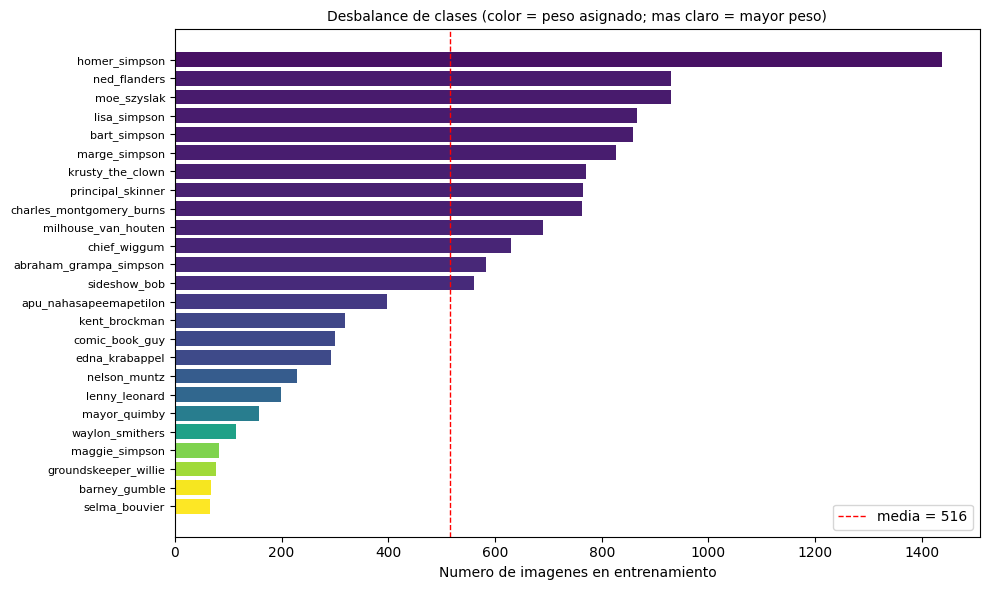

In [44]:
import matplotlib

# Distribucion de imagenes por personaje en el conjunto de entrenamiento
figura, eje = plt.subplots(figsize=(10, 6))

orden = np.argsort(conteos_train)
eje.barh(
    [clases[i] for i in orden],
    conteos_train[orden],
    color=matplotlib.colormaps["viridis"](pesos[orden] / pesos.max()),
)
eje.set_xlabel("Numero de imagenes en entrenamiento")
eje.set_title("Desbalance de clases (color = peso asignado; mas claro = mayor peso)", fontsize=10)
eje.tick_params(axis="y", labelsize=8)
eje.axvline(
    conteos_train.mean(),
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"media = {conteos_train.mean():.0f}",
)
eje.legend()

plt.tight_layout()
plt.show()


## Fundamentos: estructura de una red neuronal profunda

_Descripción teórica, apoyada en el material del curso, de los componentes que conforman la red que se implementa en la sección siguiente._

### Capas y neuronas

_Capa de entrada (dimensionada por el vector de la imagen aplanada), capas ocultas densas y capa de salida con una neurona por clase. Rol de cada una en el flujo de información._

**Que es una neurona**

La unidad basica de la red es la neurona artificial, inspirada de forma muy simplificada en la neurona
biologica: recibe varias senales de entrada, las combina dando mas importancia a unas que a otras y
produce una unica senal de salida. Toda su "inteligencia" esta en esos pesos, que son numeros que se
ajustan durante el entrenamiento.

**Como se organizan en capas**

Las neuronas no trabajan sueltas, sino agrupadas en capas, y cada capa recibe como entrada la salida de
la anterior. Una red **densa** o *fully connected* es aquella en la que cada neurona de una capa se
conecta con **todas** las neuronas de la capa siguiente. Un Perceptron Multicapa es exactamente eso:
una pila de capas densas.

| Capa | Papel en la red | En este proyecto |
|---|---|---|
| **Entrada** | No calcula nada; solo define la forma del dato que entra | 12 288 valores (el vector de 64x64x3 del pre-procesamiento) |
| **Ocultas** | Transforman progresivamente la entrada en representaciones mas utiles para separar las clases | Una o varias capas densas con activacion ReLU |
| **Salida** | Produce la prediccion en el formato del problema | 25 neuronas con softmax, una por personaje |

**Por que "profunda" y que aprenden las capas ocultas**

Se llama profunda a una red con mas de una capa oculta. La idea es que la composicion de capas construye
una **jerarquia de representaciones**: la primera capa detecta patrones muy simples a partir de los
pixeles (zonas de color, contrastes), y cada capa posterior combina los patrones de la anterior en
conceptos mas abstractos que, idealmente, terminan siendo caracteristicas discriminantes entre
personajes. Ninguna de esas caracteristicas se programa: emergen del ajuste de los pesos.

Se las llama "ocultas" simplemente porque no se observan desde fuera; solo vemos lo que entra y lo que
sale de la red.

**Ancho, profundidad y su costo**

Dos decisiones de diseno definen la arquitectura:

- **Profundidad** (cuantas capas ocultas): mas capas permiten representar funciones mas complejas, pero
  dificultan el entrenamiento y aumentan el riesgo de sobreajuste.
- **Ancho** (cuantas neuronas por capa): mas neuronas dan mas capacidad a cada nivel, a costa de muchos
  mas parametros.

Ese costo no es menor en nuestro caso. Como la entrada tiene 12 288 valores y la conexion es total, la
primera capa oculta concentra la enorme mayoria de los parametros del modelo. La siguiente celda lo
cuantifica.


In [45]:
# Cuantos parametros implica cada eleccion de ancho en la primera capa oculta
anchos_posibles = [64, 128, 256, 512, 1024]

tabla_costo = pd.DataFrame(
    {
        "neuronas_capa_1": anchos_posibles,
        # pesos (entrada x neuronas) + un sesgo por neurona
        "parametros_capa_1": [DIMENSION_ENTRADA * n + n for n in anchos_posibles],
    }
)
tabla_costo["parametros_salida"] = [n * NUMERO_CLASES + NUMERO_CLASES for n in anchos_posibles]
tabla_costo["total"] = tabla_costo["parametros_capa_1"] + tabla_costo["parametros_salida"]
tabla_costo["% en capa 1"] = (
    tabla_costo["parametros_capa_1"] / tabla_costo["total"] * 100
).round(1)
tabla_costo["memoria_MB"] = (tabla_costo["total"] * 4 / 1024 ** 2).round(1)

display(tabla_costo)

print(f"Dimension de entrada: {DIMENSION_ENTRADA} valores")
print(f"Neuronas de salida:   {NUMERO_CLASES} (una por personaje)")
print(
    "\nLa primera capa oculta concentra casi todos los parametros: es la unica"
    "\nque se conecta con los 12 288 pixeles del vector de entrada."
)


,neuronas_capa_1,parametros_capa_1,parametros_salida,total,% en capa 1,memoria_MB
0,64,786496,1625,788121,99.8,3.0
1,128,1572992,3225,1576217,99.8,6.0
2,256,3145984,6425,3152409,99.8,12.0
3,512,6291968,12825,6304793,99.8,24.1
4,1024,12583936,25625,12609561,99.8,48.1


Dimension de entrada: 12288 valores
Neuronas de salida:   25 (una por personaje)

La primera capa oculta concentra casi todos los parametros: es la unica
que se conecta con los 12 288 pixeles del vector de entrada.


### Pesos, sesgos y propagación hacia adelante

_Cómo cada neurona calcula una combinación lineal de sus entradas más un sesgo, y por qué esos parámetros son exactamente lo que el modelo aprende._

**El calculo de una neurona**

Cada neurona hace siempre lo mismo, en dos pasos:

1. **Combinacion lineal (preactivacion).** Multiplica cada entrada por su peso, suma todo y anade el
   sesgo:

   $$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

2. **Activacion.** Pasa ese numero por una funcion no lineal: $a = f(z)$.

**Que significan los pesos y el sesgo**

- El **peso** $w_i$ mide cuanto influye la entrada $x_i$ en esta neurona. Un peso grande y positivo
  indica que esa entrada empuja a la neurona a activarse; uno negativo, que la inhibe; uno cercano a cero,
  que esa entrada le resulta irrelevante. En nuestro caso cada peso de la primera capa esta asociado a un
  canal de color de un pixel concreto.
- El **sesgo** $b$ desplaza el umbral de activacion. Sin el, toda neurona estaria obligada a dar 0 cuando
  la entrada es 0, y todas las fronteras de decision tendrian que pasar por el origen. El sesgo le da
  libertad para activarse aun con entradas debiles, o para exigir una evidencia mayor.

**Pesos y sesgos son lo que el modelo aprende.** Todo lo demas -- numero de capas, neuronas, activaciones,
learning rate -- lo fijamos nosotros antes de entrenar y por eso se llaman hiperparametros. Los parametros
propiamente dichos son estos numeros, que empiezan con valores aleatorios pequenos y se van corrigiendo.

**De una neurona a una capa: forma matricial**

Escribir el calculo neurona por neurona seria impracticable. Como todas las neuronas de una capa hacen la
misma operacion sobre la misma entrada, se agrupan sus pesos en una matriz $W$ y sus sesgos en un vector
$\mathbf{b}$, y la capa entera se calcula de un golpe:

$$\mathbf{a}^{(l)} = f\left(\mathbf{a}^{(l-1)} W^{(l)} + \mathbf{b}^{(l)}\right)$$

Esto no es solo notacion elegante: es lo que permite procesar un **batch** completo de imagenes en una
sola multiplicacion de matrices, que es justo la operacion que GPU y CPU ejecutan de forma optimizada.

**Propagacion hacia adelante (forward pass)**

Se llama asi al recorrido completo: la imagen entra como vector, cada capa aplica su transformacion y
pasa el resultado a la siguiente, hasta que la capa de salida produce las 25 probabilidades. Es lo que
ocurre cada vez que el modelo predice, y tambien el primer paso de cada iteracion de entrenamiento: sin
saber que predijo la red no se puede medir cuanto se equivoco.

La celda siguiente reproduce ese recorrido a mano con NumPy, sobre una imagen real del dataset, para ver
las formas de cada matriz y comprobar que la salida es una distribucion de probabilidad.


In [46]:
# Forward pass "a mano" con una arquitectura minima: 12288 -> 64 -> 25
generador_pesos = np.random.default_rng(SEMILLA)
NEURONAS_DEMO = 64


def inicializar_capa(entradas, neuronas):
    """Pesos pequenos aleatorios (escala de He, la que usa Keras con ReLU) y sesgos a cero."""
    W = generador_pesos.normal(0, np.sqrt(2 / entradas), size=(entradas, neuronas)).astype(np.float32)
    b = np.zeros(neuronas, dtype=np.float32)
    return W, b


W1, b1 = inicializar_capa(DIMENSION_ENTRADA, NEURONAS_DEMO)
W2, b2 = inicializar_capa(NEURONAS_DEMO, NUMERO_CLASES)

# Una imagen real del conjunto de entrenamiento
entrada = X_train[0]

# Capa oculta: combinacion lineal + ReLU
z1 = entrada @ W1 + b1
a1 = np.maximum(0, z1)

# Capa de salida: combinacion lineal + softmax (se resta el maximo por estabilidad numerica)
z2 = a1 @ W2 + b2
exponenciales = np.exp(z2 - z2.max())
salida = exponenciales / exponenciales.sum()

recorrido = pd.DataFrame(
    [
        ("entrada (imagen aplanada)", str(entrada.shape), entrada.size),
        ("W1 (pesos capa oculta)", str(W1.shape), W1.size),
        ("b1 (sesgos capa oculta)", str(b1.shape), b1.size),
        ("z1 = entrada @ W1 + b1", str(z1.shape), z1.size),
        ("a1 = ReLU(z1)", str(a1.shape), a1.size),
        ("W2 (pesos capa salida)", str(W2.shape), W2.size),
        ("b2 (sesgos capa salida)", str(b2.shape), b2.size),
        ("z2 = a1 @ W2 + b2", str(z2.shape), z2.size),
        ("salida = softmax(z2)", str(salida.shape), salida.size),
    ],
    columns=["Paso", "Forma", "Numero de valores"],
)

display(recorrido)

print(f"Parametros entrenables de esta red minima: {W1.size + b1.size + W2.size + b2.size:,}")
print(f"Neuronas ocultas activas (ReLU > 0): {(a1 > 0).sum()} de {NEURONAS_DEMO}")
print(f"\nSuma de las probabilidades de salida: {salida.sum():.6f}")
print(f"Prediccion (sin entrenar): {clases[int(salida.argmax())]} con {salida.max() * 100:.1f} % de confianza")
print(f"Etiqueta real: {clases[int(y_train_idx[0])]}")
print(
    "\nCon los pesos aleatorios la prediccion es arbitraria: la red todavia no ha aprendido nada."
    "\nEntrenar consiste precisamente en corregir W1, b1, W2 y b2."
)


,Paso,Forma,Numero de valores
0,entrada (imagen aplanada),"(12288,)",12288
1,W1 (pesos capa oculta),"(12288, 64)",786432
2,b1 (sesgos capa oculta),"(64,)",64
3,z1 = entrada @ W1 + b1,"(64,)",64
4,a1 = ReLU(z1),"(64,)",64
5,W2 (pesos capa salida),"(64, 25)",1600
6,b2 (sesgos capa salida),"(25,)",25
7,z2 = a1 @ W2 + b2,"(25,)",25
8,salida = softmax(z2),"(25,)",25


Parametros entrenables de esta red minima: 788,121
Neuronas ocultas activas (ReLU > 0): 28 de 64

Suma de las probabilidades de salida: 1.000000
Prediccion (sin entrenar): maggie_simpson con 9.3 % de confianza
Etiqueta real: kent_brockman

Con los pesos aleatorios la prediccion es arbitraria: la red todavia no ha aprendido nada.
Entrenar consiste precisamente en corregir W1, b1, W2 y b2.


### Funciones de activación

**Por que hace falta la no linealidad**

Si se quitaran las funciones de activacion, cada capa seria solo una multiplicacion de matrices y la red
entera colapsaria en una sola: la composicion de funciones lineales es otra funcion lineal. Una red de
diez capas sin activaciones tendria exactamente el mismo poder expresivo que una regresion lineal, y seria
incapaz de separar clases que no se puedan dividir con un hiperplano. La activacion no lineal es lo que
permite que apilar capas sirva de algo.

**Comparacion de las activaciones para las capas ocultas**

| Funcion | Formula | Rango | Ventaja | Problema |
|---|---|---|---|---|
| **Sigmoide** | $1/(1+e^{-z})$ | (0, 1) | Interpretable como probabilidad | Se satura: para $\|z\|$ grande el gradiente tiende a 0 y el aprendizaje se detiene |
| **Tanh** | $(e^z-e^{-z})/(e^z+e^{-z})$ | (-1, 1) | Centrada en cero, converge mejor que la sigmoide | Tambien se satura en los extremos |
| **ReLU** | $\max(0, z)$ | [0, inf) | Gradiente constante 1 para $z>0$: no se satura; muy barata de calcular; produce activaciones dispersas | "Neuronas muertas": si una unidad queda siempre en $z<0$, su gradiente es 0 y no vuelve a aprender |

**Eleccion: ReLU en las capas ocultas.** El problema de la saturacion es decisivo. En una red profunda,
los gradientes se multiplican capa a capa al retropropagarse; si cada factor es menor que 1 -- como pasa
con sigmoide, cuya derivada maxima es 0,25 -- el gradiente se desvanece antes de llegar a las primeras
capas, que son justamente las que deben aprender de los pixeles. ReLU mantiene el gradiente en 1 en toda
su zona activa, y ademas su calculo es una simple comparacion, lo que acelera el entrenamiento. Es el
valor por defecto razonable para capas ocultas, y de ahi partimos.

**Eleccion: softmax en la salida.** La capa final no busca una no linealidad cualquiera, sino convertir 25
numeros sin escala definida en una distribucion de probabilidad:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{25} e^{z_j}}$$

Sus dos propiedades son las que necesita un problema multiclase de etiqueta unica: todas las salidas son
positivas y **suman exactamente 1**. Eso introduce competencia entre clases -- si sube la probabilidad de
un personaje, baja la de los demas -- que es correcto aqui, porque cada imagen tiene un unico personaje.
Si el problema fuera multietiqueta habria que usar sigmoides independientes en la salida.


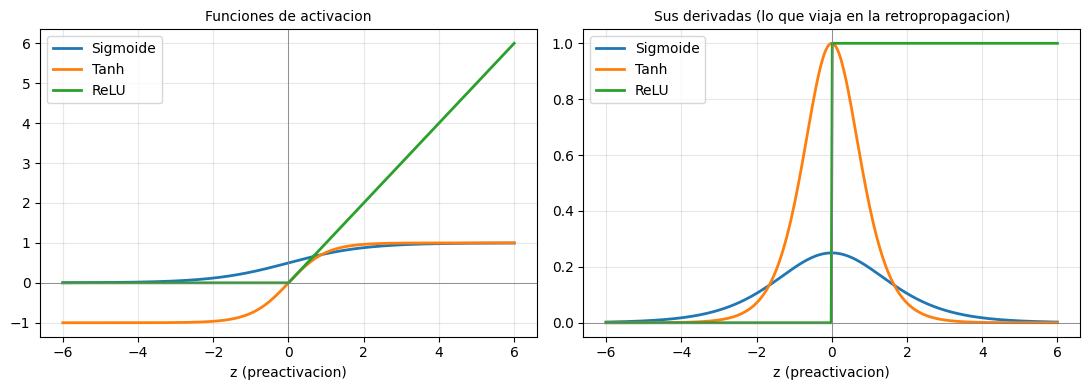

En el grafico de la derecha se ve el problema de la saturacion: las derivadas de sigmoide y tanh
caen a cero en los extremos (el gradiente se desvanece), mientras que la de ReLU vale 1 para
todo z > 0. Notese ademas que la derivada de la sigmoide no supera 0.25.


In [47]:
z = np.linspace(-6, 6, 400)

activaciones = {
    "Sigmoide": (1 / (1 + np.exp(-z)), lambda s: s * (1 - s)),
    "Tanh": (np.tanh(z), lambda s: 1 - s ** 2),
    "ReLU": (np.maximum(0, z), lambda s: (z > 0).astype(float)),
}

figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

for nombre, (valores, derivada) in activaciones.items():
    ejes[0].plot(z, valores, label=nombre, linewidth=2)
    ejes[1].plot(z, derivada(valores), label=nombre, linewidth=2)

ejes[0].set_title("Funciones de activacion", fontsize=10)
ejes[1].set_title("Sus derivadas (lo que viaja en la retropropagacion)", fontsize=10)

for eje in ejes:
    eje.axhline(0, color="gray", linewidth=0.6)
    eje.axvline(0, color="gray", linewidth=0.6)
    eje.set_xlabel("z (preactivacion)")
    eje.grid(alpha=0.3)
    eje.legend()

plt.tight_layout()
plt.show()

print(
    "En el grafico de la derecha se ve el problema de la saturacion: las derivadas de sigmoide y tanh"
    "\ncaen a cero en los extremos (el gradiente se desvanece), mientras que la de ReLU vale 1 para"
    "\ntodo z > 0. Notese ademas que la derivada de la sigmoide no supera 0.25."
)


### Función de pérdida, backpropagation y optimizador

_La entropía cruzada categórica como medida del error, la retropropagación del gradiente y la actualización de los pesos mediante descenso del gradiente / Adam._

El forward pass produce una prediccion, pero por si solo no ensena nada. El aprendizaje necesita tres
piezas mas: una forma de **medir** el error, una forma de **repartir la culpa** de ese error entre los
parametros, y una **regla** para corregirlos.

**1. Funcion de perdida: entropia cruzada categorica**

Mide la distancia entre la distribucion predicha por softmax y el vector one-hot real. Como el one-hot
tiene un 1 en la clase correcta y 0 en el resto, la suma se reduce a un unico termino:

$$L = -\sum_{i=1}^{25} y_i \log(\hat{y}_i) = -\log(\hat{y}_{\text{clase correcta}})$$

Es decir: la perdida de un ejemplo depende **solo de la probabilidad que la red asigno a la clase
verdadera**. Si le dio 0,99, la perdida es casi 0; si le dio 0,01, la perdida se dispara. Ese crecimiento
logaritmico penaliza con dureza los errores cometidos con mucha confianza, que es el comportamiento
deseable. La perdida del batch es el promedio de las perdidas individuales -- y es ahi donde `class_weight`
interviene, ponderando cada termino segun la frecuencia de su clase.

Por que no usar accuracy como funcion a minimizar: el accuracy es escalonado, su gradiente es cero en casi
todas partes y no distingue entre acertar con 0,51 o con 0,99. Sirve para interpretar resultados, no para
optimizar. Por eso se monitorean ambos: se **optimiza** la perdida y se **lee** el accuracy.

**2. Backpropagation: de donde viene el error**

Conocida la perdida, hace falta saber cuanto contribuyo cada uno de los parametros. Eso es la derivada
parcial $\partial L / \partial w$, y calcularla directamente para cientos de miles de pesos seria
inviable. La retropropagacion lo resuelve aplicando la **regla de la cadena** en sentido inverso: parte
del error en la salida y lo propaga hacia atras capa por capa, reutilizando en cada paso lo ya calculado
en la capa posterior. Esto es lo que hace posible entrenar redes grandes, y tambien la razon de que la
derivada de la activacion importe tanto: aparece como factor multiplicativo en cada capa que se atraviesa
(de ahi el desvanecimiento del gradiente con sigmoide y la ventaja de ReLU).

El resultado es el **gradiente**: un vector que indica, para cada parametro, en que direccion habria que
moverlo para que la perdida aumente. Se avanza en la direccion contraria.

**3. Optimizador: como se corrigen los pesos**

La regla basica es el **descenso del gradiente**:

$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

donde $\eta$ es la **tasa de aprendizaje** (learning rate), el tamano del paso. Demasiado grande y el
entrenamiento oscila o diverge; demasiado pequeno y avanza con una lentitud inutil. En la practica no se
calcula el gradiente sobre todo el dataset (caro) ni sobre un solo ejemplo (ruidoso), sino sobre **batches**
de unas decenas o centenas de imagenes: es el descenso del gradiente por mini-lotes. Una **epoca** es una
pasada completa por el conjunto de entrenamiento, es decir, muchas actualizaciones de pesos.

**Eleccion: Adam.** Mejora el descenso del gradiente clasico en dos aspectos: acumula un **momento** de los
gradientes anteriores, lo que suaviza las oscilaciones, y adapta el tamano del paso **para cada parametro**
segun la magnitud tipica de su gradiente. En la practica converge mas rapido y es mucho menos sensible a
la eleccion inicial del learning rate, razon por la que se usa como punto de partida en la mayoria de los
trabajos. Se parte de su valor por defecto, 0,001, y su efecto se contrasta en la experimentacion.

**El ciclo completo de entrenamiento**

Para cada batch, y repitiendolo epoca tras epoca:

`forward pass` -> `calcular la perdida` -> `backpropagation` -> `el optimizador actualiza los pesos`


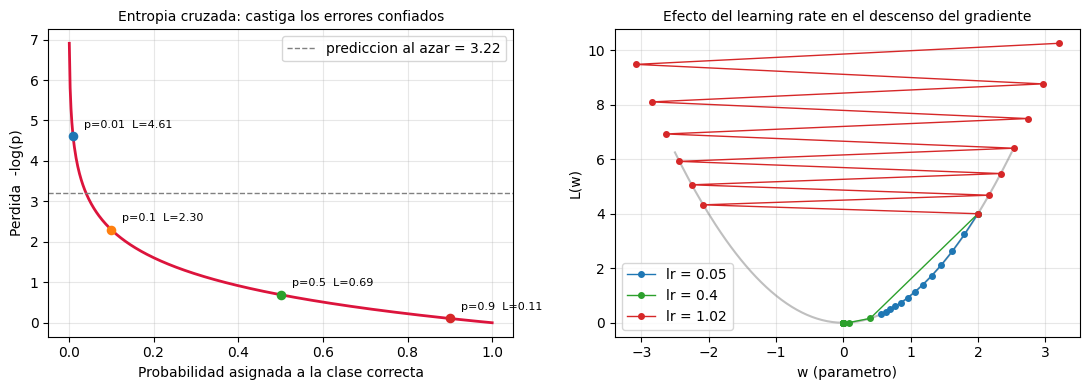

Perdida esperada de un modelo sin entrenar (1/25 a cada clase): 3.219
Es el valor de referencia con el que deberia arrancar el entrenamiento en la primera epoca.

En el grafico de la derecha: un lr pequeno (azul) converge pero lento, uno adecuado (verde)
llega rapido al minimo, y uno demasiado grande (rojo) se aleja y diverge.


In [48]:
# Perdida de un ejemplo segun la probabilidad asignada a la clase correcta
probabilidades = np.linspace(0.001, 1.0, 500)
perdidas = -np.log(probabilidades)

figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

ejes[0].plot(probabilidades, perdidas, color="crimson", linewidth=2)
ejes[0].set_xlabel("Probabilidad asignada a la clase correcta")
ejes[0].set_ylabel("Perdida  -log(p)")
ejes[0].set_title("Entropia cruzada: castiga los errores confiados", fontsize=10)
ejes[0].grid(alpha=0.3)

for probabilidad in (0.01, 0.1, 0.5, 0.9):
    ejes[0].scatter([probabilidad], [-np.log(probabilidad)], zorder=3, s=35)
    ejes[0].annotate(
        f"p={probabilidad}  L={-np.log(probabilidad):.2f}",
        (probabilidad, -np.log(probabilidad)),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=8,
    )

# Referencias del problema: perdida esperada al predecir al azar entre 25 clases
perdida_azar = -np.log(1 / NUMERO_CLASES)
ejes[0].axhline(
    perdida_azar,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"prediccion al azar = {perdida_azar:.2f}",
)
ejes[0].legend()

# Efecto del learning rate sobre el descenso del gradiente en una parabola L(w) = w^2
ejes[1].plot(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200) ** 2, color="gray", alpha=0.5)

for tasa, color in ((0.05, "tab:blue"), (0.4, "tab:green"), (1.02, "tab:red")):
    w = 2.0
    trayectoria = [w]
    for _ in range(12):
        w = w - tasa * 2 * w  # derivada de w^2
        trayectoria.append(w)
    trayectoria = np.array(trayectoria)
    ejes[1].plot(
        trayectoria,
        trayectoria ** 2,
        "o-",
        color=color,
        markersize=4,
        linewidth=1,
        label=f"lr = {tasa}",
    )

ejes[1].set_xlabel("w (parametro)")
ejes[1].set_ylabel("L(w)")
ejes[1].set_title("Efecto del learning rate en el descenso del gradiente", fontsize=10)
ejes[1].grid(alpha=0.3)
ejes[1].legend()

plt.tight_layout()
plt.show()

print(f"Perdida esperada de un modelo sin entrenar (1/{NUMERO_CLASES} a cada clase): {perdida_azar:.3f}")
print("Es el valor de referencia con el que deberia arrancar el entrenamiento en la primera epoca.")
print(
    "\nEn el grafico de la derecha: un lr pequeno (azul) converge pero lento, uno adecuado (verde)"
    "\nllega rapido al minimo, y uno demasiado grande (rojo) se aleja y diverge."
)


## Modelo base: Perceptrón Multicapa (MLP)

_Implementación del modelo base con Keras, trasladando a código los componentes descritos en "Fundamentos: estructura de una red neuronal profunda"._

### Definición de la arquitectura

_Capa de entrada con el vector aplanado, capas ocultas densas con activación ReLU, regularización (Dropout / normalización) y capa de salida de 25 neuronas con softmax._

### Justificación técnica de la arquitectura y de los hiperparámetros iniciales

_Fundamentación de: número de capas ocultas, cantidad de neuronas por capa, funciones de activación elegidas, tasa de Dropout, optimizador y tasa de aprendizaje._

### Compilación del modelo

_Optimizador, función de pérdida y métricas a monitorear durante el entrenamiento._

### Resumen del modelo

_Capas, formas de salida y número de parámetros entrenables, relacionándolo con el tamaño de entrada elegido en "Redimensionado a un tamaño fijo"._

## Entrenamiento del modelo

_Ejecución del entrenamiento del modelo base y registro del historial._

### Configuración del entrenamiento

_Número de épocas, tamaño de batch, conjunto de validación y callbacks (EarlyStopping, ModelCheckpoint)._

### Curvas de aprendizaje del modelo base

_Gráficos de pérdida y accuracy en entrenamiento y validación por época._

### Interpretación de las curvas

_Diagnóstico de sobreajuste o subajuste: separación entre las curvas de train y validación, época en que la validación deja de mejorar y efecto de la regularización._

## Experimentación: comparación de configuraciones

_Metodología de experimentación básica: partiendo del modelo base se modifica **un factor a la vez** y se compara su efecto sobre la métrica de validación, manteniendo fija la semilla y el resto de los hiperparámetros._

### Diseño de los experimentos

| Exp. | Capas ocultas | Neuronas por capa | Activación | Épocas | Batch | Learning rate | Acc. val. | F1 macro val. |
|---|---|---|---|---|---|---|---|---|
| Base | | | | | | | | |
| E1 | | | | | | | | |
| E2 | | | | | | | | |
| E3 | | | | | | | | |
| E4 | | | | | | | | |

_Tabla a completar con los resultados de cada configuración._

### Efecto del número de capas ocultas y de neuronas

_Cómo varía el desempeño al aumentar la profundidad y el ancho de la red, y cuál es su costo en parámetros y tiempo de entrenamiento._

### Efecto de la función de activación

_Comparación entre las activaciones probadas en las capas ocultas y su impacto en la convergencia._

### Efecto del número de épocas, el tamaño de batch y la tasa de aprendizaje

_Relación entre estos hiperparámetros, la estabilidad del entrenamiento y la aparición de sobreajuste._

### Selección del modelo final

_Configuración elegida y justificación técnica de la decisión a partir de la evidencia de la tabla anterior._

## Evaluación y métricas de desempeño

_Evaluación del modelo final sobre el conjunto test, no utilizado durante el entrenamiento ni durante la experimentación._

### Accuracy global sobre el conjunto de prueba

_Comparación contra los baselines definidos en "Definición del problema de clasificación" (azar 4,0 % y clase mayoritaria 11,4 %)._

### Precision, Recall y F1-Score por clase

_Reporte de clasificación por personaje, más los promedios macro y ponderado, interpretando el efecto del desbalance._

### Matriz de confusión

_Visualización de las confusiones entre clases, normalizada por fila para que el desbalance no distorsione la lectura._

### Interpretación crítica de las métricas

_Qué clases reconoce bien el modelo y cuáles no, por qué difieren accuracy y F1 macro, y qué revela esa brecha sobre el comportamiento del modelo._

## Análisis de resultados y de errores

_Revisión cualitativa de las predicciones, para entender el porqué de los aciertos y de los errores y no solo su cantidad._

### Ejemplos correctamente clasificados

_Muestra de imágenes bien predichas con su nivel de confianza, y qué características parece estar aprovechando el modelo._

### Ejemplos mal clasificados

_Muestra de imágenes con su etiqueta real, la predicha y la confianza del modelo, incluyendo errores cometidos con alta confianza._

### Confusiones más frecuentes y posibles causas

_Pares de personajes que más se confunden y discusión de las causas: similitud visual y de paleta, fondos compartidos, escenas con varios personajes, encuadres y escasez de ejemplos en clases minoritarias._

### Fortalezas y debilidades del modelo

_Síntesis crítica de lo que el MLP logra y de dónde falla de forma sistemática._

## Limitaciones del MLP en imágenes y propuestas de mejora

### Limitaciones estructurales del MLP

_Pérdida de la información espacial al aplanar la imagen, ausencia de invarianza a traslación y escala, explosión del número de parámetros respecto al tamaño de entrada, imposibilidad de reutilizar patrones locales como sí hacen los filtros convolucionales, y sensibilidad al fondo y al encuadre._

### Propuestas de mejora para futuras iteraciones

_Arquitecturas convolucionales (CNN) que preservan la estructura espacial y comparten pesos, aumento de datos, transfer learning con redes preentrenadas, mejor tratamiento del desbalance y recorte previo del personaje mediante detección._

## Conclusiones

_Síntesis de los resultados obtenidos, cumplimiento de los objetivos planteados, principales decisiones técnicas y su justificación, y aprendizajes del equipo._

## Referencias

_Fuente del dataset (Kaggle, Los Simpson - alfaro96), documentación de las librerías utilizadas (TensorFlow/Keras, scikit-learn) y material del curso._